In [ ]:
%reload_ext autoreload
%autoreload 2
import os
import sys
sys.path.insert(0, '/Users/linliu/NewSpaGRN/src/')

import anndata as ad
import pandas as pd
import scanpy as sc
import anndata as ad
import numpy as np
import spagrn
from spagrn.network import Network  # Import the Network class
from pyscenic.aucell import aucell
from scipy.spatial.distance import jensenshannon
from spagrn.plot_GRN import *
from spagrn.plot_Regulon import *
import spagrn.hotspot
import spagrn.regulatory_network

# Load data
#PDAC = ad.read_h5ad('/Users/linliu/Library/CloudStorage/Box-Box/linliu/PDAC/ad_PDAC/PDAC_SIMVI.h5ad')

In [ ]:
import os
import sys
sys.path.insert(0, '/Users/linliu/NewSpaGRN/src/')

import pandas as pd
import scanpy as sc
import anndata as ad
import numpy as np
import spagrn
from spagrn.network import Network  # Import the Network class
from pyscenic.aucell import aucell
from scipy.spatial.distance import jensenshannon
import spagrn.hotspot
import spagrn.regulatory_network

# Load data
PDAC = ad.read_h5ad('/Users/linliu/Library/CloudStorage/Box-Box/linliu/PDAC/ad_PDAC/PDAC_SIMVI.h5ad')


# Preprocess data
PDAC.X = PDAC.layers['counts']
PDAC.layers['counts'] = PDAC.layers['counts'].tocsc()
PDAC.obs['total_counts'] = np.sum(PDAC.layers['counts'], axis=1)
sc.pp.normalize_total(PDAC, target_sum=1e4)
sc.pp.log1p(PDAC)
PDAC = Network.preprocess(PDAC, min_genes=5, min_cells=20, min_counts=20, max_gene_num=4000)


# Load input files
tfs_fn = r'/Users/linliu/Library/CloudStorage/OneDrive-AugustaUniversity/GRN Analysis Input Resources/allTFs_hg38.txt'
database_fn = r'/Users/linliu/Library/CloudStorage/OneDrive-AugustaUniversity/GRN Analysis Input Resources/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather'
motif_anno_fn = r'/Users/linliu/Library/CloudStorage/OneDrive-AugustaUniversity/GRN Analysis Input Resources/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl'
niches = pd.read_csv(r'/Users/linliu/Library/CloudStorage/OneDrive-AugustaUniversity/GRN Analysis Input Resources/lr_network_human.csv')


grn = spagrn.regulatory_network.InferNetwork(adata=PDAC, project_name="PDAC_GRN")
grn.infer(
        database_fn,
        motif_anno_fn,
        tfs_fn,
        niche_df=niches,
        num_workers=20,
        cache=False,
        save_tmp=True,
        latent_obsm_key='spatial',
        model='bernoulli',
        n_neighbors=100, #Increase n_neighbors to capture broader spatial relationships
        cluster_label='niche3',
        layers='counts',
        umi_counts_obs_key="total_counts",
        batch_key='patient',
        #combine=True, #combined FDR across the four metrics (Moran's I, Geary's C, Getis-Ord G*, Hotspot) using Fisher's method 
        operation='union',  # 'union' or 'intersection'
        #local=True, #SOMDE p-values instead of global metrics
    )

/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


----------------------------------------
Project name is PDAC_GRN
Batch correction enabled using key: patient
Saving output files into /Users/linliu/NewSpaGRN/src/spagrn
Saving temporary files to /Users/linliu/NewSpaGRN/src/spagrn/tmp_files
----------------------------------------


/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely

Computing batch-aware spatial weights with batch key: patient
Computing Moran's I...


/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely

In [ ]:
PDAC.write_h5ad('/Users/linliu/Library/CloudStorage/Box-Box/linliu/PDAC/ad_PDAC/PDAC_SIMVI.h5ad')

In [2]:
PDAC.obsm['auc_mtx']

,DDIT3(+),ETS1(+),ETV4(+),FOS(+),FOXF1(+),FOXP3(+),GATA3(+),IRF3(+),IRF4(+),JUN(+),...,SMAD2(+),SMAD3(+),SOX4(+),SOX9(+),SREBF1(+),STAT1(+),STAT4(+),STAT6(+),TFEB(+),TP53(+)
B10_1_1,0.475119,0.046173,0.261702,0.057613,0.005525,0.0,0.089832,0.025862,0.082728,0.161348,...,0.095148,0.085813,0.267220,0.058239,0.209433,0.090971,0.033677,0.397066,0.025729,0.190679
B10_2_1,0.134561,0.054053,0.064994,0.023983,0.100903,0.0,0.011270,0.037750,0.000000,0.058477,...,0.072035,0.042098,0.032020,0.089431,0.108898,0.044629,0.009075,0.166127,0.049643,0.162955
B10_3_1,0.302438,0.047903,0.183510,0.039897,0.010003,0.0,0.077144,0.058497,0.144769,0.085836,...,0.119597,0.063611,0.197389,0.137646,0.217671,0.107446,0.023295,0.354870,0.060675,0.197805
B10_4_1,0.248203,0.024633,0.376193,0.039548,0.003761,0.0,0.041742,0.062901,0.073232,0.104724,...,0.047817,0.042381,0.227418,0.070811,0.196635,0.062794,0.056879,0.286832,0.015149,0.129365
B10_5_1,0.132646,0.029727,0.176726,0.157028,0.016326,0.0,0.034484,0.075189,0.153122,0.111278,...,0.050903,0.046002,0.126091,0.060717,0.095943,0.084049,0.031250,0.157630,0.000000,0.154896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA32_2519_30,0.257327,0.055798,0.000000,0.021015,0.054676,0.0,0.044631,0.000000,0.000000,0.075520,...,0.061328,0.017308,0.144606,0.060070,0.205712,0.033320,0.047782,0.288248,0.042557,0.042086
TMA32_2521_30,0.123874,0.057693,0.000000,0.023027,0.009188,0.0,0.020150,0.002317,0.255332,0.040179,...,0.045270,0.015020,0.049021,0.028245,0.041818,0.053903,0.044868,0.126291,0.230565,0.000000
TMA32_2522_30,0.145602,0.040549,0.000000,0.025212,0.023903,0.0,0.032767,0.002133,0.029895,0.031582,...,0.040254,0.028085,0.126879,0.061945,0.108236,0.020333,0.044181,0.163443,0.000000,0.000000
TMA32_2523_30,0.061373,0.018881,0.048380,0.018636,0.064127,0.0,0.024338,0.012057,0.064997,0.048904,...,0.035906,0.016971,0.061492,0.010160,0.048433,0.012958,0.009833,0.072041,0.013465,0.065552


In [3]:
PDAC.obsm['rep_auc_mtx']

,ANXA1,CD59,CTNNB1,EZR,FOS,JUNB,SOX9,XBP1,JUN
Cell,,,,,,,,,
B10_1_1,0.007653,0.006912,0.006303,0.007389,0.007389,0.006912,0.007389,0.011278,0.007389
B10_2_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
B10_3_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
B10_4_1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
B10_5_1,0.000000,0.027650,0.025210,0.029557,0.029557,0.027650,0.029557,0.003759,0.032020
...,...,...,...,...,...,...,...,...,...
TMA32_2519_30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
TMA32_2521_30,0.000000,0.018433,0.037815,0.019704,0.044335,0.018433,0.019704,0.000000,0.019704
TMA32_2522_30,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [4]:
PDAC.obsm['isr']

,DDIT3(+),ETS1(+),ETV4(+),FOS(+),FOXF1(+),FOXP3(+),GATA3(+),IRF3(+),IRF4(+),JUN(+),...,SMAD2(+),SMAD3(+),SOX4(+),SOX9(+),SREBF1(+),STAT1(+),STAT4(+),STAT6(+),TFEB(+),TP53(+)
B10_1_1,0.475119,0.046173,0.267533,0.071899,0.005525,0.000000,0.089832,0.028532,0.082728,0.161348,...,0.095148,0.085813,0.270326,0.061486,0.217155,0.090971,0.046664,0.400550,0.097158,0.204285
B10_2_1,0.134561,0.054053,0.064994,0.023983,0.100903,0.000000,0.011270,0.037750,0.000000,0.060709,...,0.072035,0.042098,0.032020,0.089431,0.108898,0.044629,0.009075,0.166127,0.049643,0.162955
B10_3_1,0.302438,0.047903,0.183510,0.039897,0.010003,0.000000,0.077144,0.058497,0.144769,0.085836,...,0.119597,0.063611,0.197389,0.137646,0.217671,0.107446,0.023295,0.354870,0.060675,0.197805
B10_4_1,0.248203,0.024633,0.376193,0.039548,0.003761,0.000000,0.041742,0.062901,0.073232,0.104724,...,0.047817,0.042381,0.227418,0.070811,0.196635,0.062794,0.056879,0.286832,0.015149,0.129365
B10_5_1,0.132646,0.029727,0.176726,0.196314,0.016326,0.010989,0.034484,0.083867,0.176932,0.123555,...,0.070546,0.046002,0.126091,0.069645,0.095943,0.084049,0.066965,0.167212,0.000000,0.154896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA32_2519_30,0.257327,0.055798,0.007289,0.038872,0.054676,0.000000,0.044631,0.003338,0.000000,0.075520,...,0.070256,0.026237,0.148488,0.064128,0.215365,0.040919,0.047782,0.292603,0.042557,0.059093
TMA32_2521_30,0.123874,0.057693,0.000000,0.058742,0.009188,0.000000,0.020150,0.023678,0.255332,0.051340,...,0.063127,0.015020,0.052903,0.036362,0.041818,0.061502,0.106556,0.142841,0.230565,0.000000
TMA32_2522_30,0.145602,0.040549,0.000000,0.025212,0.023903,0.000000,0.032767,0.002133,0.029895,0.031582,...,0.040254,0.028085,0.126879,0.061945,0.108236,0.020333,0.044181,0.163443,0.000000,0.000000
TMA32_2523_30,0.061373,0.018881,0.048380,0.018636,0.064127,0.000000,0.024338,0.015395,0.064997,0.048904,...,0.035906,0.016971,0.065374,0.010160,0.048433,0.020556,0.009833,0.072041,0.013465,0.065552


In [5]:
PDAC.uns['adj']

,TF,target,importance
0,EOMES,RPS4Y1,0.017527
1,EOMES,KRT15,0.006224
2,EOMES,IFNGR1,0.013316
3,EOMES,FFAR4,0.007050
4,EOMES,ADGRL2,0.007008
...,...,...,...
74795,SREBF1,HLA-DRA,0.025304
74796,SREBF1,CD209,0.014361
74797,SREBF1,COL6A2,0.019578
74798,SREBF1,CD63,0.045965


<Figure size 800x700 with 0 Axes>

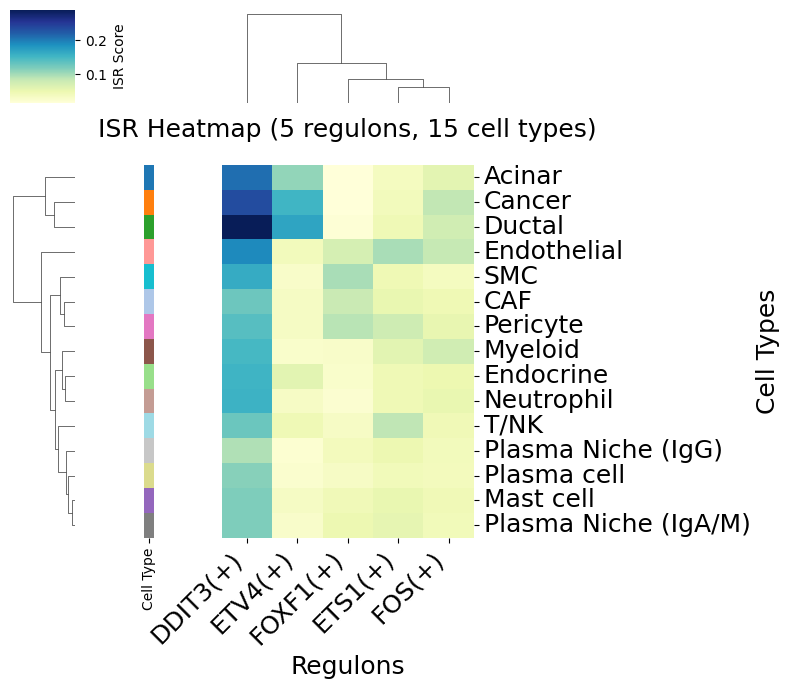

Heatmap created with:
  - 15 cell types: Acinar, CAF, Cancer, Ductal, Endocrine, Endothelial, Mast cell, Myeloid, Neutrophil, Pericyte, Plasma Niche (IgA/M), Plasma Niche (IgG), Plasma cell, SMC, T/NK
  - 5 regulons
  - Data range: 0.014 to 0.290


,ETS1(+),DDIT3(+),FOS(+),ETV4(+),FOXF1(+)
Acinar,0.036688,0.209149,0.057508,0.107969,0.014811
CAF,0.052088,0.127749,0.045641,0.032953,0.080906
Cancer,0.040077,0.235438,0.085645,0.152247,0.014360
Ductal,0.045380,0.289557,0.074738,0.168488,0.018209
Endocrine,0.044667,0.153970,0.049656,0.059126,0.026968
Endothelial,0.097324,0.191575,0.083290,0.039169,0.071174
Mast cell,0.052514,0.118056,0.044018,0.033588,0.042616
Myeloid,0.058985,0.149206,0.074586,0.027208,0.029319
Neutrophil,0.045026,0.156177,0.053035,0.032140,0.022266
Pericyte,0.077559,0.139505,0.053257,0.032664,0.090207


In [8]:
# Show top 5 (ranked by rss) regulons per cell type
from spagrn.plot_Regulon import isr_heatmap

isr_heatmap(
    PDAC,
    cluster_label='niche3',
    isr_mtx=PDAC.obsm['isr'],
    rss_df=PDAC.uns['rss'],
    topn=5,  # Top 5 regulons per cell type
    figsize=(8, 7),
    cmap="YlGnBu",
    xticklabels=True,
    yticklabels=True
)

Excluded cell types: ['Plasma cell']
Remaining cell types: ['Acinar', 'CAF', 'Cancer', 'Ductal', 'Endocrine', 'Endothelial', 'Mast cell', 'Myeloid', 'Neutrophil', 'Pericyte', 'Plasma Niche (IgA/M)', 'Plasma Niche (IgG)', 'SMC', 'T/NK']


<Figure size 2000x700 with 0 Axes>

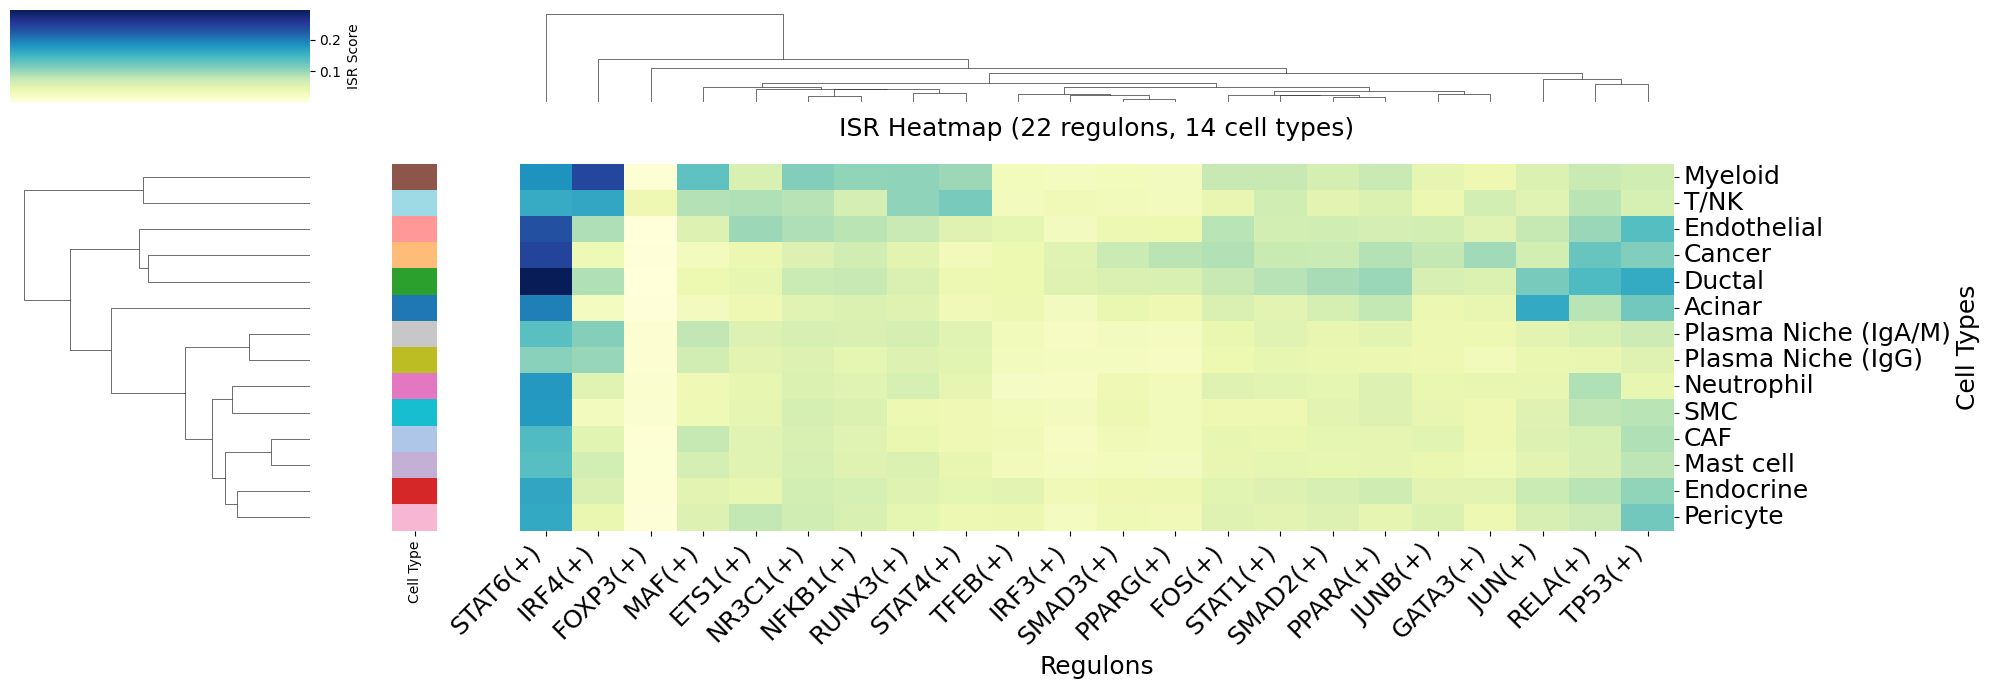

Heatmap created with:
  - 14 cell types: Acinar, CAF, Cancer, Ductal, Endocrine, Endothelial, Mast cell, Myeloid, Neutrophil, Pericyte, Plasma Niche (IgA/M), Plasma Niche (IgG), SMC, T/NK
  - 22 regulons: ETS1(+), IRF3(+), RELA(+), IRF4(+), TP53(+), NR3C1(+), SMAD3(+), PPARG(+), JUN(+), SMAD2(+), PPARA(+), JUNB(+), GATA3(+), MAF(+), STAT1(+), FOXP3(+), TFEB(+), STAT6(+), RUNX3(+), FOS(+), STAT4(+), NFKB1(+)
  - Data range: 0.002 to 0.294


In [70]:
#Viral/inflammatory response regulons
# For averaged cell type heatmap with selected regulons
heatmap_data = isr_heatmap(
    PDAC,
    cluster_label='niche3',
    isr_mtx=PDAC.obsm['isr'],
    rss_df=PDAC.uns['rss'],
    selected_regulons=['ETS1(+)', 'FOS(+)', 'FOXP3(+)', 'GATA3(+)', 'IRF3(+)', 'IRF4(+)', 
                       'JUN(+)', 'JUNB(+)', 'MAF(+)', 'NFKB1(+)', 'NR3C1(+)', 'PPARA(+)', 
                       'PPARG(+)', 'RELA(+)', 'RUNX3(+)', 'SMAD2(+)', 'SMAD3(+)', 
                       'STAT1(+)', 'STAT4(+)', 'STAT6(+)', 'TFEB(+)', 'TP53(+)'],  # Only show IRF3 and IRF4
    excluded_cell_types=['Plasma cell'],
    figsize=(20, 7),
    cmap="YlGnBu",
    xticklabels=True,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True
)

<Figure size 2000x700 with 0 Axes>

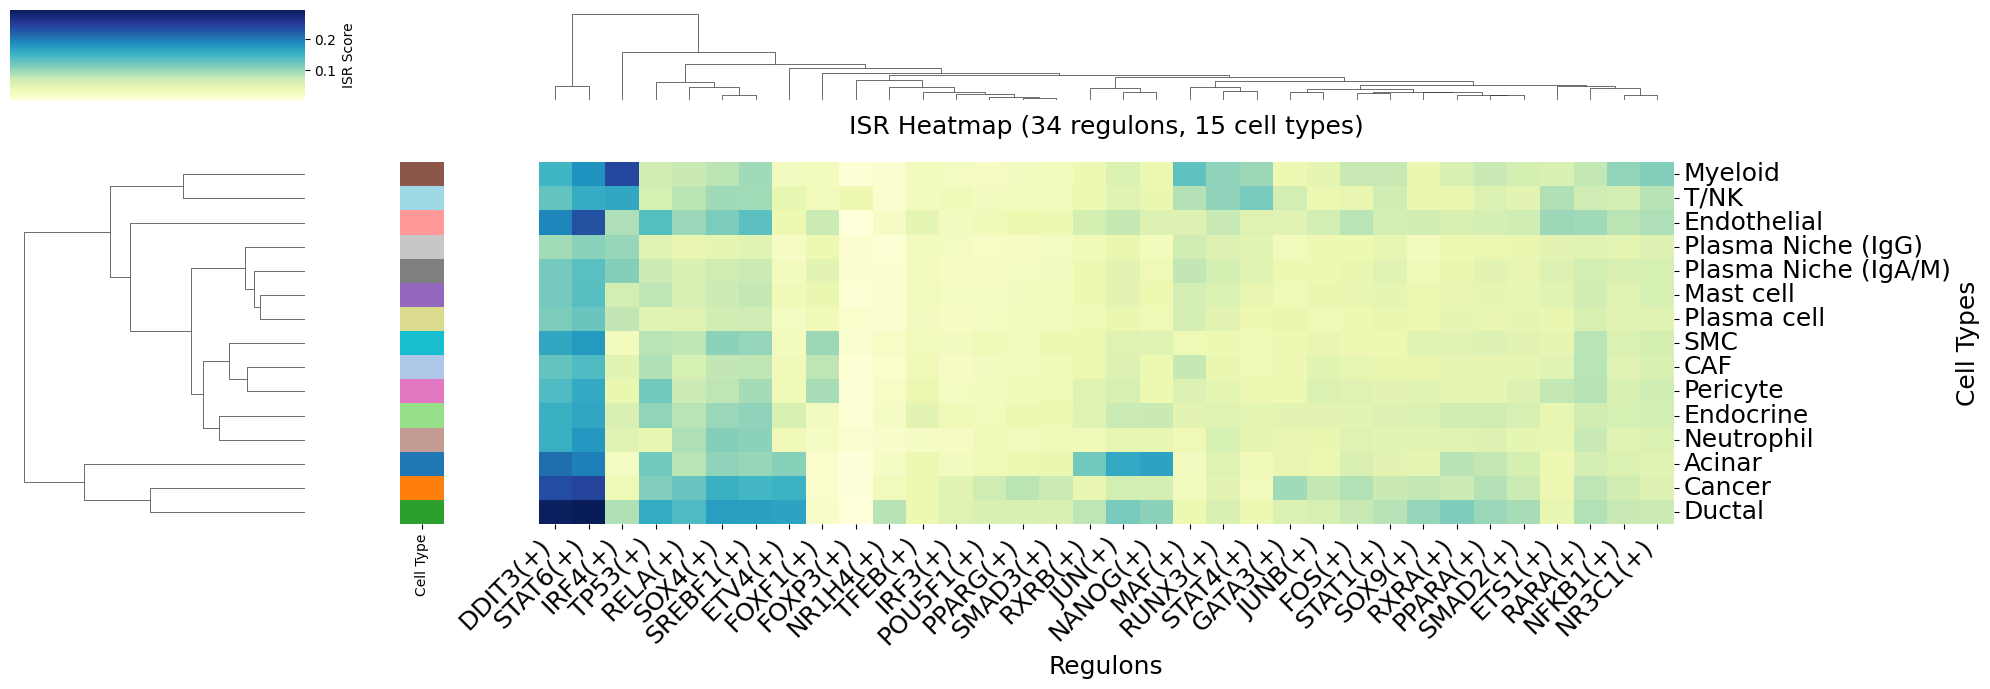

Heatmap created with:
  - 15 cell types: Acinar, CAF, Cancer, Ductal, Endocrine, Endothelial, Mast cell, Myeloid, Neutrophil, Pericyte, Plasma Niche (IgA/M), Plasma Niche (IgG), Plasma cell, SMC, T/NK
  - 34 regulons: DDIT3(+), ETS1(+), ETV4(+), FOS(+), FOXF1(+), FOXP3(+), GATA3(+), IRF3(+), IRF4(+), JUN(+), JUNB(+), MAF(+), NANOG(+), NFKB1(+), NR1H4(+), NR3C1(+), POU5F1(+), PPARA(+), PPARG(+), RARA(+), RELA(+), RUNX3(+), RXRA(+), RXRB(+), SMAD2(+), SMAD3(+), SOX4(+), SOX9(+), SREBF1(+), STAT1(+), STAT4(+), STAT6(+), TFEB(+), TP53(+)
  - Data range: 0.002 to 0.294


,DDIT3(+),ETS1(+),ETV4(+),FOS(+),FOXF1(+),FOXP3(+),GATA3(+),IRF3(+),IRF4(+),JUN(+),...,SMAD2(+),SMAD3(+),SOX4(+),SOX9(+),SREBF1(+),STAT1(+),STAT4(+),STAT6(+),TFEB(+),TP53(+)
Acinar,0.209149,0.036688,0.107969,0.057508,0.014811,0.004422,0.044522,0.026913,0.025856,0.161192,...,0.062506,0.041488,0.104939,0.046081,0.100250,0.048232,0.033285,0.196498,0.038013,0.118985
CAF,0.127749,0.052088,0.032953,0.045641,0.080906,0.007593,0.036683,0.023530,0.049825,0.054456,...,0.047805,0.032034,0.078499,0.041999,0.079539,0.041745,0.036396,0.139877,0.034163,0.087321
Cancer,0.235438,0.040077,0.152247,0.085645,0.014360,0.004523,0.095386,0.050970,0.034826,0.064369,...,0.071783,0.070832,0.154532,0.077371,0.146830,0.071995,0.030644,0.243345,0.039683,0.110970
Ductal,0.289557,0.045380,0.168488,0.074738,0.018209,0.002388,0.056676,0.052715,0.087286,0.115453,...,0.092162,0.058218,0.172163,0.100513,0.170097,0.084390,0.038530,0.294141,0.039334,0.159876
Endocrine,0.153970,0.044667,0.059126,0.049656,0.026968,0.007290,0.048343,0.032608,0.057849,0.071715,...,0.059427,0.036790,0.098460,0.056452,0.103853,0.054561,0.047686,0.165014,0.048881,0.102824
Endothelial,0.191575,0.097324,0.039169,0.083290,0.071174,0.002632,0.050947,0.026983,0.087909,0.075776,...,0.067107,0.038807,0.113490,0.065442,0.132301,0.064605,0.052674,0.233693,0.047758,0.136862
Mast cell,0.118056,0.052514,0.033588,0.044018,0.042616,0.009040,0.035334,0.024541,0.065039,0.049112,...,0.045487,0.029352,0.070288,0.040157,0.077361,0.046962,0.043782,0.135377,0.031252,0.080834
Myeloid,0.149206,0.058985,0.027208,0.074586,0.029319,0.007630,0.037580,0.025682,0.241570,0.056730,...,0.061773,0.029070,0.081672,0.043278,0.094906,0.075234,0.097350,0.182512,0.028773,0.066534
Neutrophil,0.156177,0.045026,0.032140,0.053035,0.022266,0.013493,0.043984,0.023383,0.051260,0.045034,...,0.046925,0.036270,0.108509,0.049593,0.105840,0.049868,0.046277,0.177883,0.022353,0.045308
Pericyte,0.139505,0.077559,0.032664,0.053257,0.090207,0.006211,0.038362,0.025745,0.041984,0.059452,...,0.054143,0.035391,0.080464,0.049615,0.093128,0.048121,0.038626,0.161787,0.040788,0.118768


In [25]:
# Show all regulons per cell type
from spagrn.plot_Regulon import isr_heatmap
isr_heatmap(
    PDAC,
    cluster_label='niche3',
    isr_mtx=PDAC.obsm['isr'],  # Use directly - it's already a DataFrame
    rss_df=PDAC.uns['rss'],
    topn=None,  # Show all regulons
    figsize=(20, 7),
    cmap="YlGnBu",
    xticklabels=True,
    yticklabels=True,
    row_cluster=True,
    col_cluster=True
)

In [9]:
# Get network (TF->Target) significance range
import numpy as np
from spagrn.plot_GRN import get_network_summary

# Get the network summary
summary = get_network_summary(PDAC, receptor_source='receptor_dict')

# Extract and print the importance range
min_importance = summary.get('min_importance', None)
max_importance = summary.get('max_importance', None)

if min_importance is not None and max_importance is not None:
    print(f"Importance Range: {min_importance} to {max_importance}")
else:
    print("No importance data found in adata.uns['adj']")

Importance Range: -0.03372185560282114 to 0.3361574686251469


In [ ]:
#Compute spatial correlation matrix for ALL genes
correlation_matrix, correlation_z = compute_global_spatial_correlation_matrix(
    PDAC, batch_key='patient', save_path='PDAC_spatial_correlations', cache=True
)

Computing global spatial correlation matrix for 965 genes...
Using batch-corrected spatial correlation
Creating spatial neighborhood graph...
Computing pairwise spatial correlations...


100%|██████████| 965/965 [02:28<00:00,  6.50it/s]
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/linliu/miniconda3/envs/newspagrn/lib/python3.8/site-packages/

Computed correlation matrix: (965, 965)
Saved correlation matrices to PDAC_spatial_correlations_*.csv


Filtering receptors for TF: IRF4
Analyzing 6 candidate receptors vs 8 target genes
Found 6/6 receptors and 8/8 targets in correlation matrix
  CD2: mean_corr = 0.0470 (range: 0.0240 to 0.0689), mean_z = 45.4758 (range: 25.9980 to 67.6770)
  CD37: mean_corr = 0.0647 (range: 0.0424 to 0.0819), mean_z = 60.7570 (range: 46.3460 to 78.9392)
  IL10RA: mean_corr = 0.0651 (range: 0.0452 to 0.0809), mean_z = 61.4115 (range: 48.9341 to 78.4386)
  IL7R: mean_corr = 0.0778 (range: 0.0346 to 0.1163), mean_z = 68.1370 (range: 31.7315 to 107.2012)
  IL2RG: mean_corr = 0.0394 (range: 0.0222 to 0.0596), mean_z = 36.8219 (range: 24.0998 to 48.4071)
  CXCR4: mean_corr = 0.0960 (range: 0.0601 to 0.1308), mean_z = 79.9912 (range: 52.5420 to 114.9328)

Filtering results:
  Total candidate receptors: 6
  Available in correlation matrix: 6
  Above thresholds (corr >= 0.05, z >= 5.5): 4
  Selected top 2 (overriding thresholds and percentage): 2

Top filtered receptors for IRF4 (by mean):
  1. CXCR4: mean_corr 

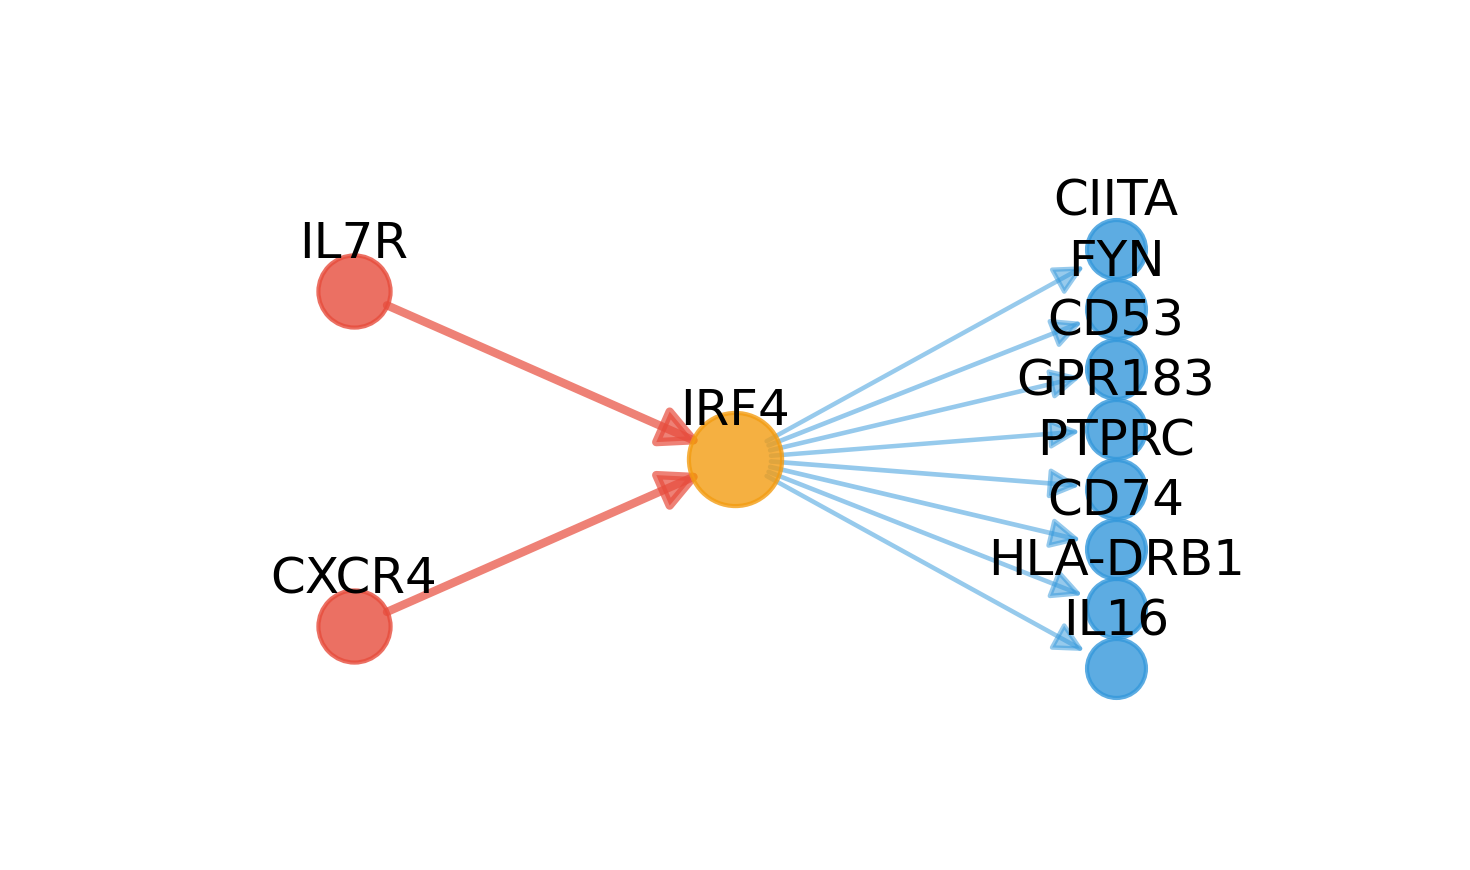

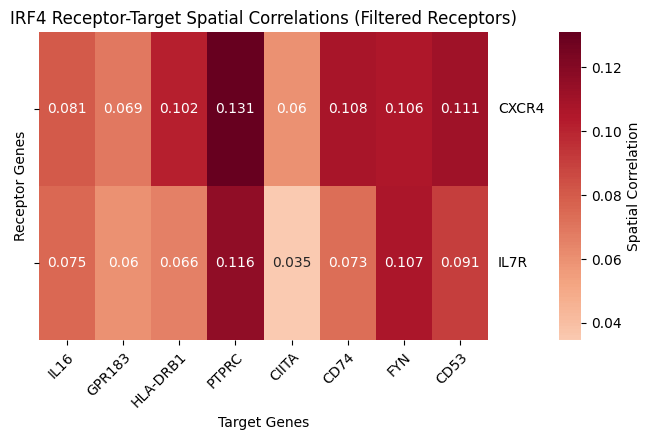

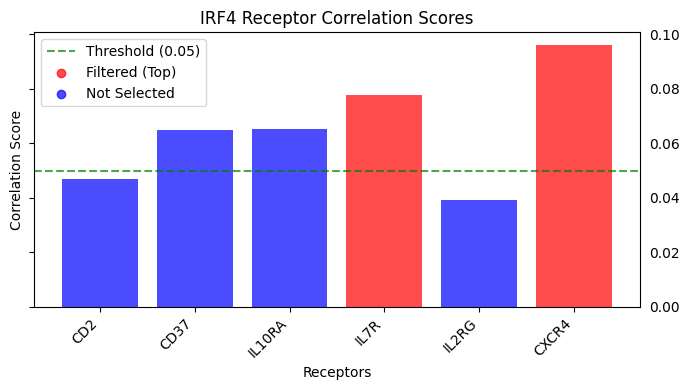

Receptor: ['CXCR4', 'IL7R']. 
TF: ['IRF4'], 
Target: ['IL16', 'HLA-DRB1', 'CD74', 'PTPRC', 'GPR183', 'CD53', 'FYN', 'CIITA']


In [153]:
#IRF4 centered GRN network plot with receptor filtering
fig, G = plot_grn_network(
    PDAC,
    receptor_source='receptor_dict',
    selected_tfs=['IRF4'],
    show_receptor=True,  # Exclude receptor nodes and edges
    min_importance=0.02, # Target genes with importance score >= 
    filter_receptor=True,
    correlation_matrix=correlation_matrix,
    correlation_z=correlation_z,
    top_n=2, # Overide
    top_percent=1,  # Keep top ratio
    min_correlation_threshold=0.05,
    min_z_threshold= 5.5, # p<0.00000005
    figsize=(5, 3),
    title='', # No title
    show_legend=False,
    show_heatmap=True,
    show_score_dist=True,
    heatmap_figsize=(7, 4),     
    score_dist_figsize=(7, 4)    
)

Filtering receptors for TF: IRF3
Analyzing 107 candidate receptors vs 10 target genes
Found 107/107 receptors and 10/10 targets in correlation matrix
  CD40: mean_corr = -0.0009 (range: -0.0111 to 0.0069), mean_z = -0.4240 (range: -7.0498 to 6.4174)
  IFNGR1: mean_corr = 0.0096 (range: -0.0123 to 0.0238), mean_z = 9.0128 (range: -8.6836 to 21.3434)
  ITGB4: mean_corr = 0.0995 (range: 0.0437 to 0.1767), mean_z = 76.4531 (range: 30.7590 to 120.5683)
  CD81: mean_corr = -0.0014 (range: -0.0533 to 0.0342), mean_z = 1.0791 (range: -33.5892 to 34.1823)
  BCL2: mean_corr = -0.0240 (range: -0.0557 to 0.0098), mean_z = -18.4059 (range: -35.2923 to 8.8073)
  ICAM3: mean_corr = -0.0116 (range: -0.0229 to 0.0025), mean_z = -8.8358 (range: -14.5225 to 2.2717)
  IL10RB: mean_corr = 0.0245 (range: 0.0140 to 0.0383), mean_z = 19.8245 (range: 11.2151 to 28.7643)
  CCR7: mean_corr = -0.0164 (range: -0.0355 to 0.0012), mean_z = -12.4559 (range: -23.8885 to 1.1178)
  IL1R1: mean_corr = -0.0208 (range: -0.

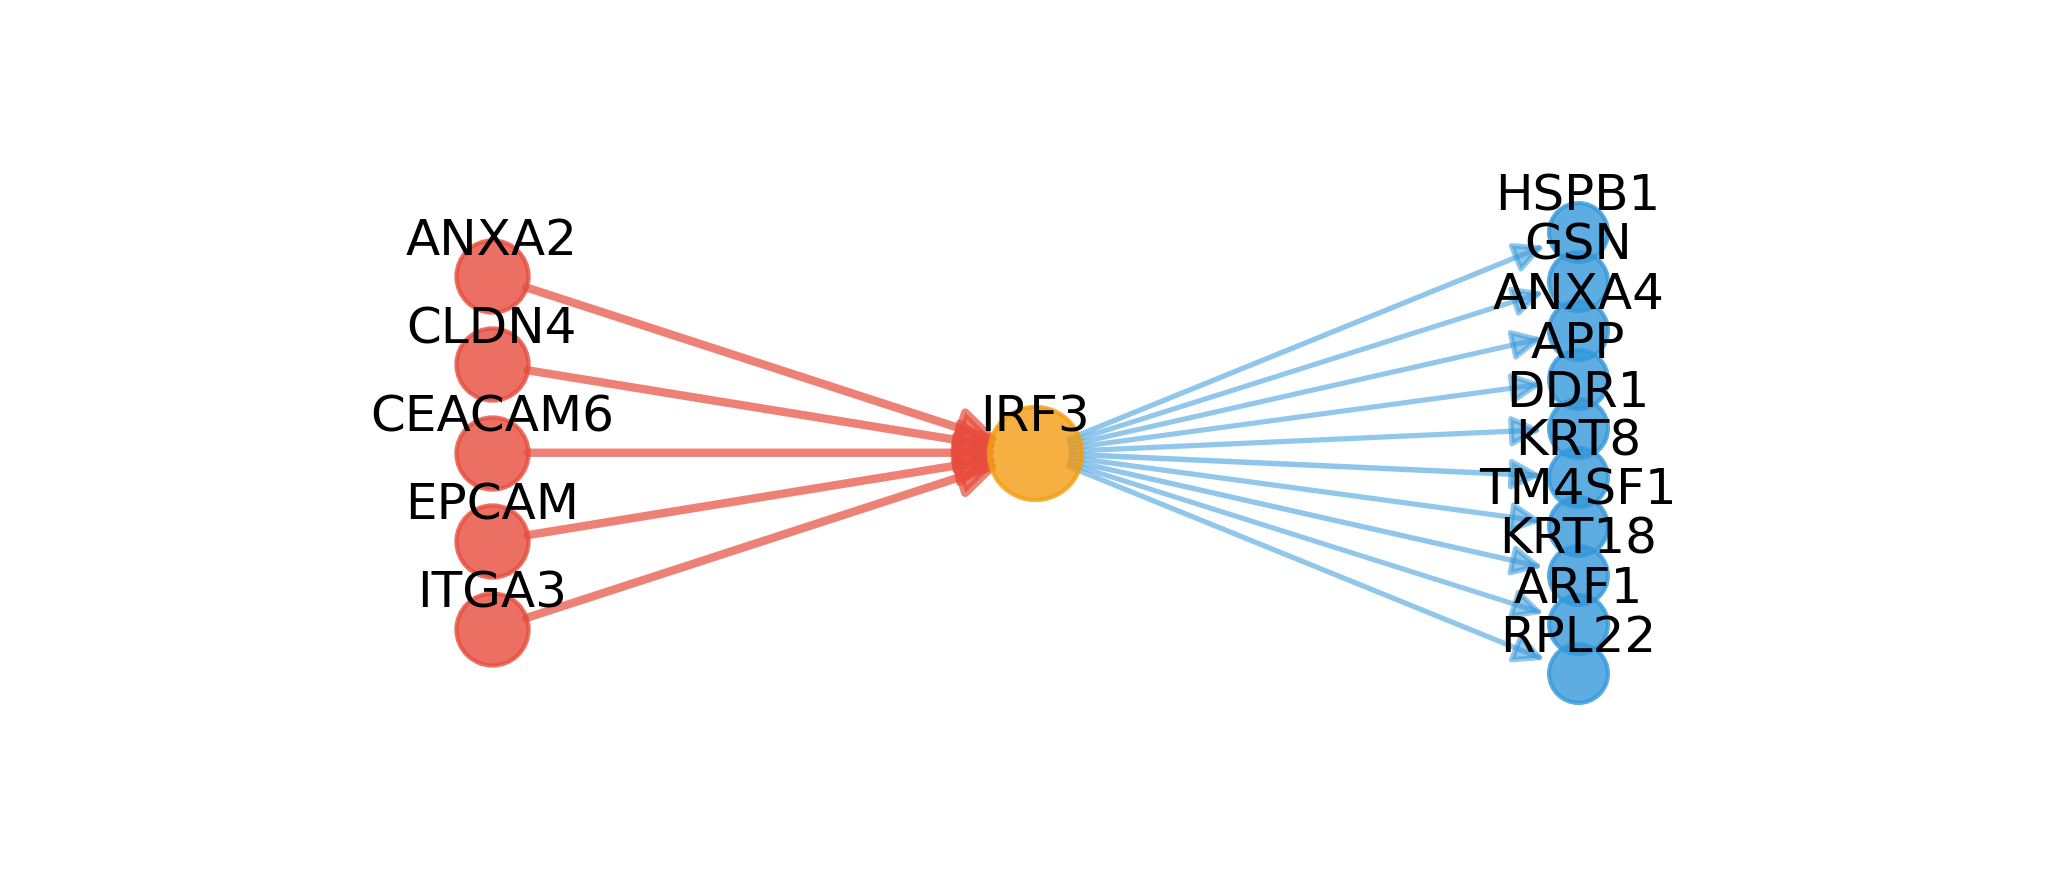

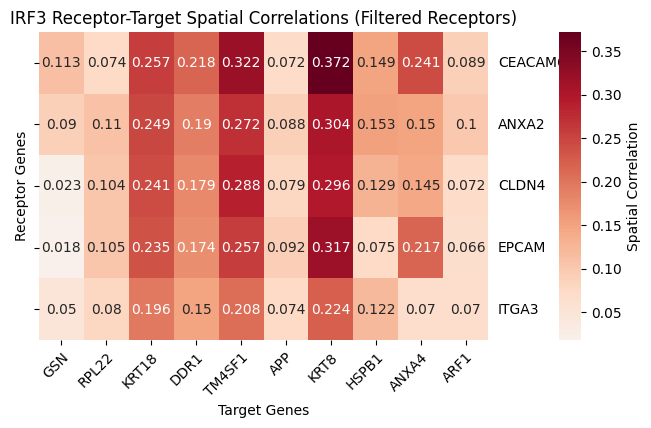

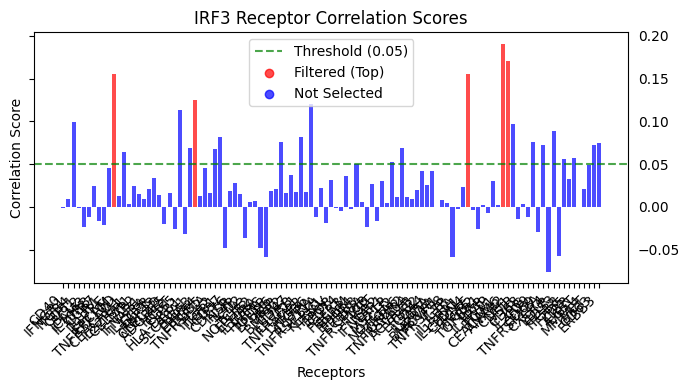

Receptor: ['ITGA3', 'EPCAM', 'CEACAM6', 'CLDN4', 'ANXA2']. 
TF: ['IRF3'], 
Target: ['RPL22', 'ARF1', 'KRT18', 'TM4SF1', 'KRT8', 'DDR1', 'APP', 'ANXA4', 'GSN', 'HSPB1']


In [154]:
#IRF4 centered GRN network plot with receptor filtering
fig, G = plot_grn_network(
    PDAC,
    receptor_source='receptor_dict',
    selected_tfs=['IRF3'],
    show_receptor=True,  # Exclude receptor nodes and edges
    min_importance=0.07, # Target genes with importance score >= 
    filter_receptor=True,
    correlation_matrix=correlation_matrix,
    correlation_z=correlation_z,
    top_n=5, # Overide
    top_percent=1,  # Keep top ratio
    min_correlation_threshold=0.05,
    min_z_threshold= 5.5, # p<0.00000005
    figsize=(7, 3),
    title='', # No title
    show_legend=False,
    show_heatmap=True,
    show_score_dist=True,
    heatmap_figsize=(7, 4),     
    score_dist_figsize=(7, 4)    
)

In [152]:
PDAC.uns['receptor_dict_filtered']

{'IRF3': ['CEACAM6', 'ANXA2']}